# Ensemble Learning – Random Forest

## Objective
Train a Random Forest model and compare it with Decision Tree

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
data = load_wine()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9444444444444444


In [5]:
# Train random forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [6]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.944444
1  Random Forest  1.000000


In [7]:
importance = rf_model.feature_importances_

features = pd.Series(importance)
print(features.sort_values(ascending=False))

6     0.202293
9     0.171202
12    0.139046
0     0.112398
11    0.111564
10    0.070891
4     0.036841
1     0.035703
3     0.032425
5     0.029279
8     0.023561
2     0.021282
7     0.013515
dtype: float64


In [8]:
for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    print(n, rf.score(X_test, y_test))

10 0.9444444444444444
50 1.0
100 1.0
200 1.0


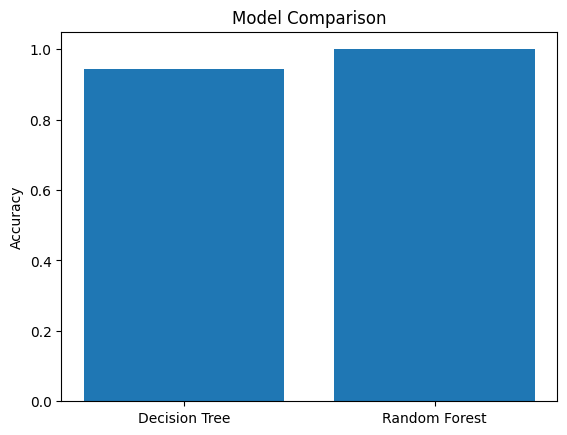

In [9]:
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest"]
scores = [dt_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()